## Setup and Imports

In [86]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [87]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
print("NLTK data downloaded successfully!")

NLTK data downloaded successfully!


## Data Loading

In [88]:
# Load the Amazon dataset
data_path = 'sentiment labelled sentences/amazon_cells_labelled.txt'
df = pd.read_csv(data_path, sep='\t', header=None, names=['text', 'label'])

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 2)

Label distribution:
label
0    500
1    500
Name: count, dtype: int64

First 5 rows:


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [89]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print(f"\nTotal samples: {len(df)}")
print(f"Positive samples: {(df['label'] == 1).sum()}")
print(f"Negative samples: {(df['label'] == 0).sum()}")

Missing values:
text     0
label    0
dtype: int64

Total samples: 1000
Positive samples: 500
Negative samples: 500


---
# Task 1: Text Preprocessing (30%)

Apply preprocessing steps:
1. Remove punctuation
2. Remove numbers
3. Convert to lowercase
4. Remove stop words
5. Lemmatization

## Select Example Sentences

Choose 3 diverse examples to demonstrate preprocessing steps

In [90]:
# Select 3 example sentences for detailed preprocessing demonstration
example_indices = [0, 50, 100]  # Diverse examples
example_texts = df.iloc[example_indices]['text'].tolist()

print("Original Example Sentences:")
for i, text in enumerate(example_texts, 1):
    print(f"\nExample {i}: {text}")

Original Example Sentences:

Example 1: So there is no way for me to plug it in here in the US unless I go by a converter.

Example 2: Not loud enough and doesn't turn on like it should.

Example 3: Integrated seamlessly with the Motorola RAZR phone.


## Step 1: Remove Punctuation

In [91]:
def remove_punctuation(text):
    """Remove all punctuation from text"""
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply to examples
step1_examples = [remove_punctuation(text) for text in example_texts]

# Display results
print("Step 1: Remove Punctuation\n" + "="*60)
for i in range(len(example_texts)):
    print(f"\nExample {i+1}:")
    print(f"Before: {example_texts[i]}")
    print(f"After:  {step1_examples[i]}")
    
# Apply to entire dataset
df['text_step1'] = df['text'].apply(remove_punctuation)

Step 1: Remove Punctuation

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter.
After:  So there is no way for me to plug it in here in the US unless I go by a converter

Example 2:
Before: Not loud enough and doesn't turn on like it should.
After:  Not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone.
After:  Integrated seamlessly with the Motorola RAZR phone


## Step 2: Remove Numbers

In [92]:
def remove_numbers(text):
    """Remove all numbers from text"""
    return re.sub(r'\d+', '', text)

# Apply to examples
step2_examples = [remove_numbers(text) for text in step1_examples]

# Display results
print("Step 2: Remove Numbers\n" + "="*60)
for i in range(len(step1_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step1_examples[i]}")
    print(f"After:  {step2_examples[i]}")
    
# Apply to entire dataset
df['text_step2'] = df['text_step1'].apply(remove_numbers)

Step 2: Remove Numbers

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter
After:  So there is no way for me to plug it in here in the US unless I go by a converter

Example 2:
Before: Not loud enough and doesnt turn on like it should
After:  Not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone
After:  Integrated seamlessly with the Motorola RAZR phone


## Step 3: Convert to Lowercase

In [93]:
def to_lowercase(text):
    """Convert text to lowercase"""
    return text.lower()

# Apply to examples
step3_examples = [to_lowercase(text) for text in step2_examples]

# Display results
print("Step 3: Convert to Lowercase\n" + "="*60)
for i in range(len(step2_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step2_examples[i]}")
    print(f"After:  {step3_examples[i]}")
    
# Apply to entire dataset
df['text_step3'] = df['text_step2'].apply(to_lowercase)

Step 3: Convert to Lowercase

Example 1:
Before: So there is no way for me to plug it in here in the US unless I go by a converter
After:  so there is no way for me to plug it in here in the us unless i go by a converter

Example 2:
Before: Not loud enough and doesnt turn on like it should
After:  not loud enough and doesnt turn on like it should

Example 3:
Before: Integrated seamlessly with the Motorola RAZR phone
After:  integrated seamlessly with the motorola razr phone


## Step 4: Remove Stop Words

In [94]:
# Get English stop words
stop_words = set(stopwords.words('english'))
print(f"Number of stop words: {len(stop_words)}")
print(f"\nFirst 20 stop words: {list(stop_words)[:20]}")

Number of stop words: 198

First 20 stop words: ['was', "i'd", 'it', 'own', "they'll", 'be', 'you', 'itself', "they've", 'whom', "didn't", 'herself', "we'd", 'won', 'hasn', 'being', "shouldn't", "needn't", 'd', 'has']


In [95]:
def remove_stopwords(text):
    """Remove stop words from text"""
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Apply to examples
step4_examples = [remove_stopwords(text) for text in step3_examples]

# Display results
print("Step 4: Remove Stop Words\n" + "="*60)
for i in range(len(step3_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step3_examples[i]}")
    print(f"After:  {step4_examples[i]}")
    # Show removed words
    before_words = set(step3_examples[i].split())
    after_words = set(step4_examples[i].split())
    removed = before_words - after_words
    print(f"Removed: {removed}")
    
# Apply to entire dataset
df['text_step4'] = df['text_step3'].apply(remove_stopwords)

Step 4: Remove Stop Words

Example 1:
Before: so there is no way for me to plug it in here in the us unless i go by a converter
After:  way plug us unless go converter
Removed: {'no', 'so', 'it', 'is', 'here', 'there', 'by', 'for', 'me', 'the', 'in', 'to', 'i', 'a'}

Example 2:
Before: not loud enough and doesnt turn on like it should
After:  loud enough doesnt turn like
Removed: {'should', 'it', 'not', 'and', 'on'}

Example 3:
Before: integrated seamlessly with the motorola razr phone
After:  integrated seamlessly motorola razr phone
Removed: {'with', 'the'}


## Step 5: Lemmatization

In [96]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Lemmatize all words in text"""
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# Apply to examples
step5_examples = [lemmatize_text(text) for text in step4_examples]

# Display results
print("Step 5: Lemmatization\n" + "="*60)
for i in range(len(step4_examples)):
    print(f"\nExample {i+1}:")
    print(f"Before: {step4_examples[i]}")
    print(f"After:  {step5_examples[i]}")
    # Show word changes
    before_words = step4_examples[i].split()
    after_words = step5_examples[i].split()
    changes = [(b, a) for b, a in zip(before_words, after_words) if b != a]
    if changes:
        print(f"Changed: {changes}")
    else:
        print("Changed: None")
    
# Apply to entire dataset
df['text_preprocessed'] = df['text_step4'].apply(lemmatize_text)

Step 5: Lemmatization

Example 1:
Before: way plug us unless go converter
After:  way plug u unless go converter
Changed: [('us', 'u')]

Example 2:
Before: loud enough doesnt turn like
After:  loud enough doesnt turn like
Changed: None

Example 3:
Before: integrated seamlessly motorola razr phone
After:  integrated seamlessly motorola razr phone
Changed: None


## Summary: Complete Preprocessing Pipeline

In [97]:
# Create summary table for examples
preprocessing_summary = pd.DataFrame({
    'Step': ['Original', '1. Remove Punctuation', '2. Remove Numbers', 
             '3. Lowercase', '4. Remove Stopwords', '5. Lemmatization'],
    'Example 1': [example_texts[0], step1_examples[0], step2_examples[0], 
                  step3_examples[0], step4_examples[0], step5_examples[0]],
    'Example 2': [example_texts[1], step1_examples[1], step2_examples[1], 
                  step3_examples[1], step4_examples[1], step5_examples[1]],
    'Example 3': [example_texts[2], step1_examples[2], step2_examples[2], 
                  step3_examples[2], step4_examples[2], step5_examples[2]]
})

print("\nPreprocessing Pipeline Summary:")
print("="*100)
preprocessing_summary


Preprocessing Pipeline Summary:


,Step,Example 1,Example 2,Example 3
0,Original,So there is no way for me to plug it in here i...,Not loud enough and doesn't turn on like it sh...,Integrated seamlessly with the Motorola RAZR p...
1,1. Remove Punctuation,So there is no way for me to plug it in here i...,Not loud enough and doesnt turn on like it should,Integrated seamlessly with the Motorola RAZR p...
2,2. Remove Numbers,So there is no way for me to plug it in here i...,Not loud enough and doesnt turn on like it should,Integrated seamlessly with the Motorola RAZR p...
3,3. Lowercase,so there is no way for me to plug it in here i...,not loud enough and doesnt turn on like it should,integrated seamlessly with the motorola razr p...
4,4. Remove Stopwords,way plug us unless go converter,loud enough doesnt turn like,integrated seamlessly motorola razr phone
5,5. Lemmatization,way plug u unless go converter,loud enough doesnt turn like,integrated seamlessly motorola razr phone


In [98]:
# Show statistics of preprocessing impact
print("\nPreprocessing Impact Statistics:")
print("="*60)
print(f"Average word count before: {df['text'].str.split().str.len().mean():.2f}")
print(f"Average word count after: {df['text_preprocessed'].str.split().str.len().mean():.2f}")
print(f"Average reduction: {(1 - df['text_preprocessed'].str.split().str.len().mean() / df['text'].str.split().str.len().mean()) * 100:.2f}%")

# Show first few preprocessed texts
print("\nFirst 5 preprocessed texts:")
for i in range(5):
    print(f"\n{i+1}. Original: {df.iloc[i]['text']}")
    print(f"   Processed: {df.iloc[i]['text_preprocessed']}")


Preprocessing Impact Statistics:
Average word count before: 10.25
Average word count after: 5.28
Average reduction: 48.47%

First 5 preprocessed texts:

1. Original: So there is no way for me to plug it in here in the US unless I go by a converter.
   Processed: way plug u unless go converter

2. Original: Good case, Excellent value.
   Processed: good case excellent value

3. Original: Great for the jawbone.
   Processed: great jawbone

4. Original: Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
   Processed: tied charger conversation lasting minutesmajor problem

5. Original: The mic is great.
   Processed: mic great


---
# Task 2: Bag-of-Words Classification (30%)

Classify sentiment using 3 algorithms:
1. Logistic Regression
2. Naive Bayes (MultinomialNB)
3. Random Forest

## Feature Extraction: TF-IDF

In [99]:
# Create TF-IDF features (optimized for 1000 documents)
tfidf = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8)
X = tfidf.fit_transform(df['text_preprocessed'])
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nTop 20 features: {tfidf.get_feature_names_out()[:20]}")

Feature matrix shape: (1000, 654)
Number of features: 654
Number of samples: 1000

Top 20 features: ['ability' 'able' 'absolutely' 'accept' 'access' 'actually' 'adapter'
 'additional' 'adorable' 'advertised' 'advise' 'ago' 'allows' 'almost'
 'alone' 'along' 'also' 'although' 'always' 'amazed']


## Train-Test Split

In [100]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set label distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 800
Test set size: 200

Training set label distribution:
label
1    400
0    400
Name: count, dtype: int64

Test set label distribution:
label
1    100
0    100
Name: count, dtype: int64


## Algorithm 1: Logistic Regression

In [101]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"\nLogistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

Training Logistic Regression...

Logistic Regression Results:
Accuracy:  0.7750
Precision: 0.7835
Recall:    0.7600
F1-Score:  0.7716

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78       100
    Positive       0.78      0.76      0.77       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



## Algorithm 2: Naive Bayes

In [102]:
# Train Naive Bayes
print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)

# Evaluation
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"\nNaive Bayes Results:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

Training Naive Bayes...

Naive Bayes Results:
Accuracy:  0.7850
Precision: 0.7522
Recall:    0.8500
F1-Score:  0.7981

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.72      0.77       100
    Positive       0.75      0.85      0.80       100

    accuracy                           0.79       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.79      0.78       200



## Algorithm 3: Random Forest

In [103]:
# Train Random Forest (optimized hyperparameters)
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=None,  # Allow trees to grow fully
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\nRandom Forest Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Negative', 'Positive']))

Training Random Forest...

Random Forest Results:
Accuracy:  0.7650
Precision: 0.7789
Recall:    0.7400
F1-Score:  0.7590

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.79      0.77       100
    Positive       0.78      0.74      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



## Comparison of All Algorithms

In [104]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [lr_accuracy, nb_accuracy, rf_accuracy],
    'Precision': [lr_precision, nb_precision, rf_precision],
    'Recall': [lr_recall, nb_recall, rf_recall],
    'F1-Score': [lr_f1, nb_f1, rf_f1]
})

print("\nAlgorithm Comparison:")
print("="*70)
print(comparison_df.to_string(index=False))

# Find best algorithm
best_algo = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Algorithm']
print(f"\nBest performing algorithm (by F1-Score): {best_algo}")


Algorithm Comparison:
          Algorithm  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.775   0.783505    0.76  0.771574
        Naive Bayes     0.785   0.752212    0.85  0.798122
      Random Forest     0.765   0.778947    0.74  0.758974

Best performing algorithm (by F1-Score): Naive Bayes


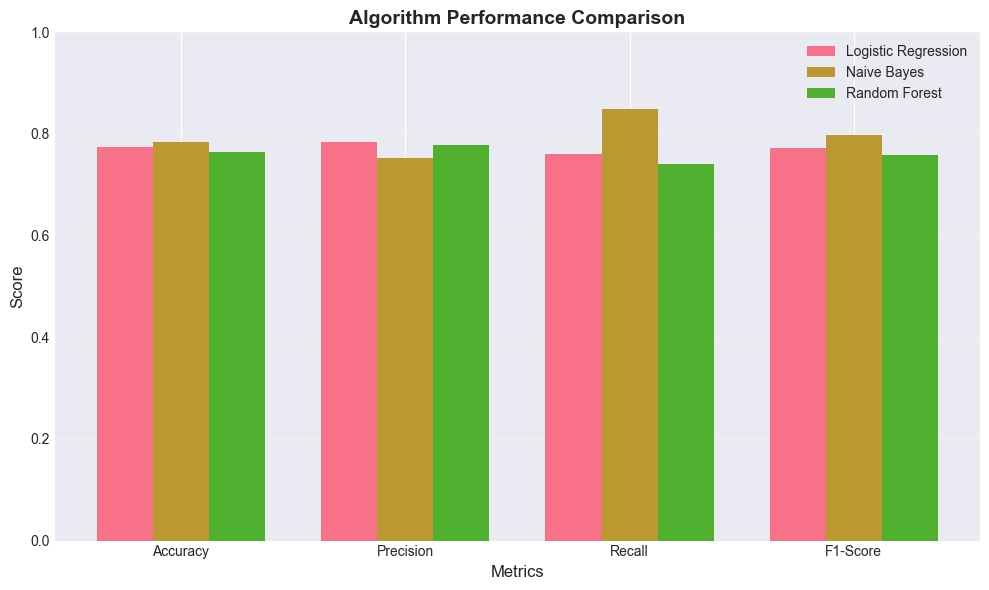

In [105]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

ax.bar(x - width, comparison_df.iloc[0][1:], width, label='Logistic Regression')
ax.bar(x, comparison_df.iloc[1][1:], width, label='Naive Bayes')
ax.bar(x + width, comparison_df.iloc[2][1:], width, label='Random Forest')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Algorithm Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Confusion Matrices

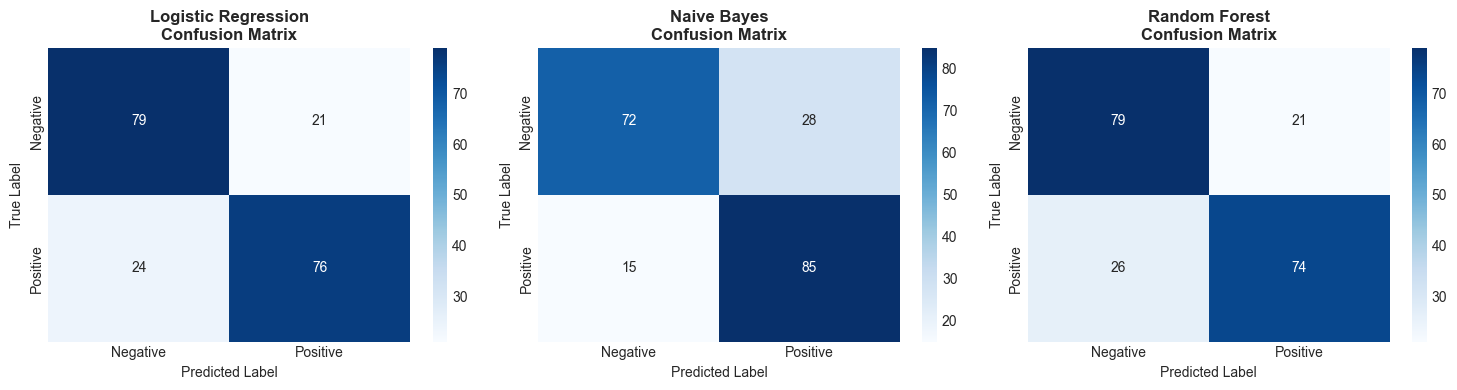

In [106]:
# Create confusion matrices for all three algorithms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

algorithms = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
predictions = [lr_pred, nb_pred, rf_pred]

for idx, (algo, pred, ax) in enumerate(zip(algorithms, predictions, axes)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{algo}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [107]:
# Print detailed confusion matrix analysis
for algo, pred in zip(algorithms, predictions):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{algo}:")
    print("="*50)
    print(f"True Negatives:  {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives:  {tp}")
    print(f"Total Correct:   {tn + tp} / {len(y_test)}")
    print(f"Total Incorrect: {fp + fn} / {len(y_test)}")


Logistic Regression:
True Negatives:  79
False Positives: 21
False Negatives: 24
True Positives:  76
Total Correct:   155 / 200
Total Incorrect: 45 / 200

Naive Bayes:
True Negatives:  72
False Positives: 28
False Negatives: 15
True Positives:  85
Total Correct:   157 / 200
Total Incorrect: 43 / 200

Random Forest:
True Negatives:  79
False Positives: 21
False Negatives: 26
True Positives:  74
Total Correct:   153 / 200
Total Incorrect: 47 / 200


## Feature Importance (Random Forest)

Top 20 Most Important Features (Random Forest):
    feature  importance
      great    0.098573
       good    0.057583
       well    0.032069
  excellent    0.030608
      phone    0.023321
       love    0.022453
      price    0.021025
       best    0.020755
       work    0.019567
       easy    0.018837
       nice    0.017324
comfortable    0.015639
  recommend    0.013797
     better    0.011818
    headset    0.011228
      first    0.010902
    product    0.010563
       dont    0.010399
       case    0.009777
       poor    0.009420


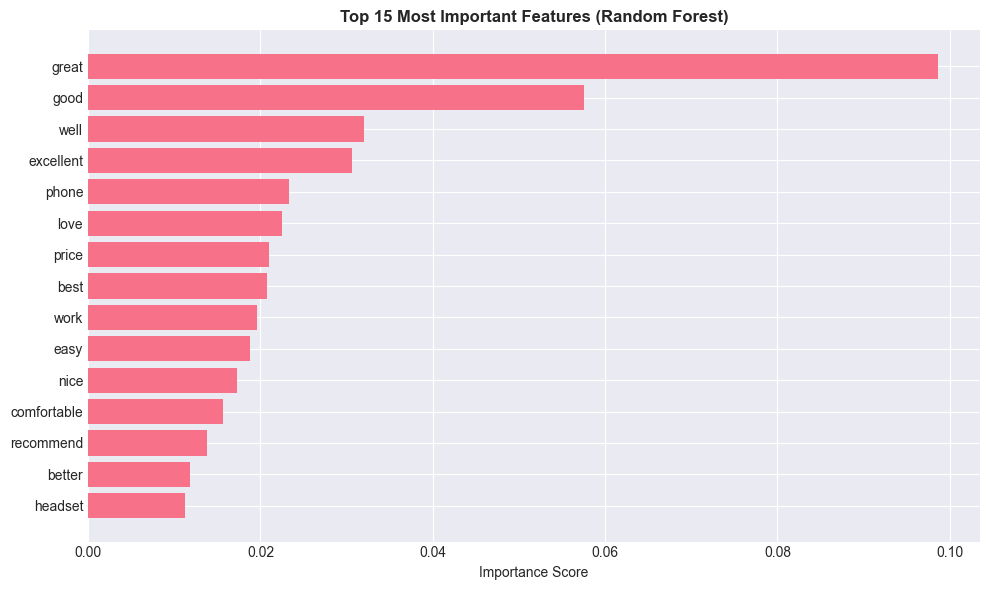

In [108]:
# Get top 20 most important features from Random Forest
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features (Random Forest):")
print("="*50)
print(feature_importance.head(20).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [109]:
# Save results for Task 2
print("\n" + "="*70)
print("TASK 2 COMPLETE")
print("="*70)
print(f"\nBest Algorithm: {best_algo}")
print(f"Best F1-Score: {comparison_df['F1-Score'].max():.4f}")
print("\nAll algorithms trained and evaluated successfully!")


TASK 2 COMPLETE

Best Algorithm: Naive Bayes
Best F1-Score: 0.7981

All algorithms trained and evaluated successfully!


---
# Task 3: BERT Classification (10%)

Fine-tune DistilBERT for sentiment classification and compare with traditional methods

## Install Transformers Library

(Run if not already installed)

In [110]:
# Install transformers and datasets (uncomment if needed)
# !pip install transformers datasets torch

# Import BERT-related libraries
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.9.1+cpu
CUDA available: False
Using device: cpu


## Prepare Data for BERT

Use original text (not preprocessed) as BERT handles its own tokenization

In [111]:
# Prepare data splits for BERT (using original text, not preprocessed)
# Use same train-test split as Task 2 for fair comparison
train_indices = y_train.index
test_indices = y_test.index

train_texts = df.loc[train_indices, 'text'].tolist()
test_texts = df.loc[test_indices, 'text'].tolist()
train_labels = y_train.tolist()
test_labels = y_test.tolist()

print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(f"\nExample training text: {train_texts[0]}")
print(f"Label: {train_labels[0]}")

Training samples: 800
Test samples: 200

Example training text: I love this cable - it allows me to connect any mini-USB device to my PC.
Label: 1


## Initialize Tokenizer and Model

In [112]:
# Load pre-trained DistilBERT model and tokenizer
model_name = "distilbert-base-uncased"
print(f"Loading {model_name}...")

tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2  # Binary classification
)

model.to(device)
print(f"Model loaded successfully on {device}")

Loading distilbert-base-uncased...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully on cpu


## Tokenize Data

In [113]:
# Tokenize the texts
print("Tokenizing data...")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# Create datasets
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels
})

print(f"Training dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")
print(f"\nExample tokenized input shape: {len(train_encodings['input_ids'][0])} tokens")

Tokenizing data...
Training dataset: 800 samples
Test dataset: 200 samples

Example tokenized input shape: 44 tokens


## Define Training Configuration

In [114]:
# Define training arguments (optimized for speed)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",  # Don't save checkpoints to save disk space
    load_best_model_at_end=False,
    report_to="none"  # Disable wandb/tensorboard
)

print("Training configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")

Training configuration:
  Epochs: 3
  Batch size: 16
  Learning rate: 2e-05


## Fine-tune the Model

In [115]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train the model
print("\nStarting BERT fine-tuning...")
print("="*60)
start_time = time.time()

trainer.train()

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


Starting BERT fine-tuning...


Epoch,Training Loss,Validation Loss
1,0.522700,0.311776
2,0.201800,0.279911
3,0.110300,0.289221



Training completed in 252.05 seconds (4.20 minutes)


## Evaluate BERT Model

In [116]:
# Make predictions
print("Making predictions on test set...")
predictions = trainer.predict(test_dataset)
bert_pred = np.argmax(predictions.predictions, axis=1)

# Calculate metrics
bert_accuracy = accuracy_score(test_labels, bert_pred)
bert_precision = precision_score(test_labels, bert_pred)
bert_recall = recall_score(test_labels, bert_pred)
bert_f1 = f1_score(test_labels, bert_pred)

print(f"\nBERT (DistilBERT) Results:")
print("="*60)
print(f"Accuracy:  {bert_accuracy:.4f}")
print(f"Precision: {bert_precision:.4f}")
print(f"Recall:    {bert_recall:.4f}")
print(f"F1-Score:  {bert_f1:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, bert_pred, target_names=['Negative', 'Positive']))

Making predictions on test set...



BERT (DistilBERT) Results:
Accuracy:  0.9000
Precision: 0.9167
Recall:    0.8800
F1-Score:  0.8980

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.92      0.90       100
    Positive       0.92      0.88      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



## Compare BERT with Traditional Algorithms

In [117]:
# Add BERT to comparison
final_comparison = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'BERT (DistilBERT)'],
    'Accuracy': [lr_accuracy, nb_accuracy, rf_accuracy, bert_accuracy],
    'Precision': [lr_precision, nb_precision, rf_precision, bert_precision],
    'Recall': [lr_recall, nb_recall, rf_recall, bert_recall],
    'F1-Score': [lr_f1, nb_f1, rf_f1, bert_f1]
})

print("\nFinal Algorithm Comparison (All Methods):")
print("="*80)
print(final_comparison.to_string(index=False))

# Highlight best performer
best_overall = final_comparison.loc[final_comparison['F1-Score'].idxmax(), 'Algorithm']
best_f1 = final_comparison['F1-Score'].max()
print(f"\nBest performing algorithm overall: {best_overall} (F1-Score: {best_f1:.4f})")


Final Algorithm Comparison (All Methods):
          Algorithm  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.775   0.783505    0.76  0.771574
        Naive Bayes     0.785   0.752212    0.85  0.798122
      Random Forest     0.765   0.778947    0.74  0.758974
  BERT (DistilBERT)     0.900   0.916667    0.88  0.897959

Best performing algorithm overall: BERT (DistilBERT) (F1-Score: 0.8980)


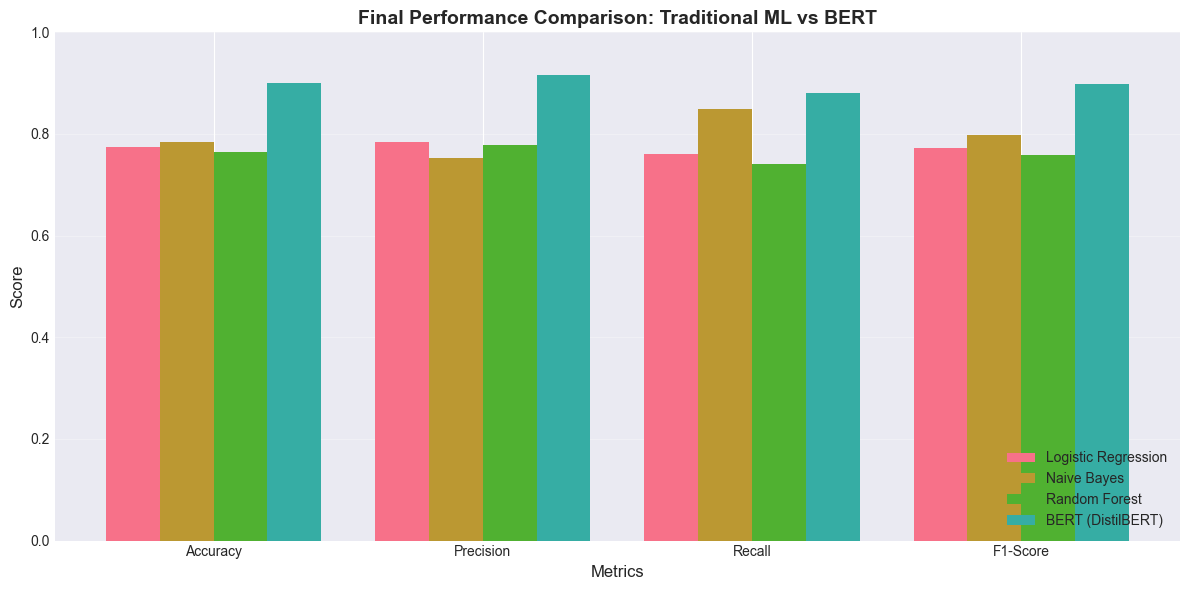

In [118]:
# Visualize final comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

ax.bar(x - 1.5*width, final_comparison.iloc[0][1:], width, label='Logistic Regression')
ax.bar(x - 0.5*width, final_comparison.iloc[1][1:], width, label='Naive Bayes')
ax.bar(x + 0.5*width, final_comparison.iloc[2][1:], width, label='Random Forest')
ax.bar(x + 1.5*width, final_comparison.iloc[3][1:], width, label='BERT (DistilBERT)')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Performance Comparison: Traditional ML vs BERT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

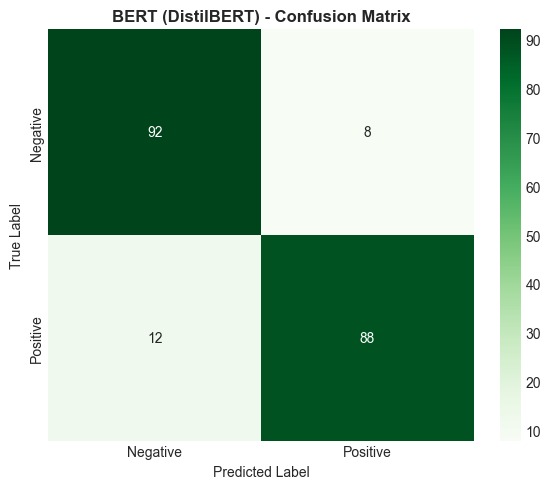


BERT Confusion Matrix Breakdown:
True Negatives:  92
False Positives: 8
False Negatives: 12
True Positives:  88
Total Correct:   180 / 200


In [119]:
# BERT Confusion Matrix
bert_cm = confusion_matrix(test_labels, bert_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_title('BERT (DistilBERT) - Confusion Matrix', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print confusion matrix details
tn, fp, fn, tp = bert_cm.ravel()
print(f"\nBERT Confusion Matrix Breakdown:")
print("="*50)
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"Total Correct:   {tn + tp} / {len(test_labels)}")

In [120]:
print("\n" + "="*70)
print("TASK 3 COMPLETE")
print("="*70)
print(f"\nBERT F1-Score: {bert_f1:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print("\nBERT fine-tuning and evaluation completed successfully!")


TASK 3 COMPLETE

BERT F1-Score: 0.8980
Training time: 252.05 seconds

BERT fine-tuning and evaluation completed successfully!


---
# Task 4: Topic Detection (30%)

Apply Latent Dirichlet Allocation (LDA) with 10 topics to discover themes in the reviews

## Import Topic Modeling Libraries

In [121]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

print("Libraries loaded for topic modeling")

Libraries loaded for topic modeling


## Prepare Data for Topic Modeling

Use preprocessed text from Task 1

In [122]:
# Use preprocessed text for topic modeling
documents = df['text_preprocessed'].tolist()

print(f"Total documents for topic modeling: {len(documents)}")
print(f"\nExample preprocessed document:")
print(documents[0])

Total documents for topic modeling: 1000

Example preprocessed document:
way plug u unless go converter


## Create Document-Term Matrix

In [123]:
# Create CountVectorizer for LDA (uses raw term counts)
vectorizer = CountVectorizer(
    max_features=1000,  # Limit to top 1000 words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.8          # Word must not appear in more than 80% of documents
)

doc_term_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print(f"Document-term matrix shape: {doc_term_matrix.shape}")
print(f"Number of unique terms: {len(feature_names)}")
print(f"\nSample terms: {feature_names[:30]}")

Document-term matrix shape: (1000, 654)
Number of unique terms: 654

Sample terms: ['ability' 'able' 'absolutely' 'accept' 'access' 'actually' 'adapter'
 'additional' 'adorable' 'advertised' 'advise' 'ago' 'allows' 'almost'
 'alone' 'along' 'also' 'although' 'always' 'amazed' 'amazon' 'another'
 'anyone' 'anything' 'appears' 'area' 'around' 'arrived' 'ask' 'att']


## Train LDA Model with 10 Topics

In [124]:
# Initialize and train LDA model (optimized for convergence)
n_topics = 10
print(f"Training LDA model with {n_topics} topics...")

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=50,  # Increased for better convergence
    learning_method='online',
    learning_offset=10.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lda_model.fit(doc_term_matrix)

print(f"LDA model trained successfully!")
print(f"Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

Training LDA model with 10 topics...
LDA model trained successfully!
Perplexity: 720.10
Log-likelihood: -28271.61


## Extract and Display Topics

In [125]:
# Function to display topics
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append({
            'Topic': topic_idx,
            'Top Words': ', '.join(top_words)
        })
    return pd.DataFrame(topics)

# Get top 15 words per topic
n_top_words = 15
topics_df = display_topics(lda_model, feature_names, n_top_words)

print("="*100)
print(f"LDA TOPICS (Top {n_top_words} words per topic)")
print("="*100)
for idx, row in topics_df.iterrows():
    print(f"\nTopic {row['Topic']}: {row['Top Words']}")

LDA TOPICS (Top 15 words per topic)

Topic 0: phone, great, new, get, first, cell, volume, also, worked, time, highly, day, got, motorola, horrible

Topic 1: better, much, ive, people, hear, talk, id, expected, cost, experience, trouble, expect, construction, despite, cheaper

Topic 2: work, charger, great, car, fine, charge, doesnt, take, plug, disappointed, nokia, phone, perfectly, keep, like

Topic 3: headset, sound, service, love, ever, bluetooth, quality, use, easy, thing, worst, bad, button, month, great

Topic 4: good, product, price, im, excellent, purchase, far, case, amazon, really, found, real, one, internet, shipping

Topic 5: phone, use, call, device, bought, used, design, impressed, back, feature, didnt, could, drop, going, want

Topic 6: battery, ear, problem, comfortable, piece, life, reception, junk, headset, jabra, useless, stay, received, hour, quickly

Topic 7: well, dont, make, phone, best, fit, time, one, ive, happy, product, great, still, money, waste

Topic 8: w

## Interpret Topics

Assign meaningful labels to each topic based on top words

In [126]:
# Manual interpretation of topics based on top words
topic_interpretations = {
    0: "Phone Quality & Performance - General cell phone experiences and quality assessments",
    1: "Call Quality & Expectations - Voice call clarity and user expectations",
    2: "Charging & Accessories - Charger functionality and car accessories",
    3: "Headset & Audio - Bluetooth headsets and sound quality",
    4: "Purchase Satisfaction - Product value and buying experience",
    5: "Device Features & Usage - Phone features and user experience",
    6: "Battery & Comfort - Battery life and wearing comfort issues",
    7: "Overall Satisfaction - General product satisfaction and fit",
    8: "Recommendations - Product recommendations and usability",
    9: "Build Quality - Materials and construction quality concerns"
}

topics_df['Interpretation'] = topics_df['Topic'].map(topic_interpretations)

print("\nTopic Interpretations:")
print("="*100)
for idx, row in topics_df.iterrows():
    print(f"\nTopic {row['Topic']}: {row['Interpretation']}")
    print(f"  Key words: {', '.join(row['Top Words'].split(', ')[:5])}")


Topic Interpretations:

Topic 0: Phone Quality & Performance - General cell phone experiences and quality assessments
  Key words: phone, great, new, get, first

Topic 1: Call Quality & Expectations - Voice call clarity and user expectations
  Key words: better, much, ive, people, hear

Topic 2: Charging & Accessories - Charger functionality and car accessories
  Key words: work, charger, great, car, fine

Topic 3: Headset & Audio - Bluetooth headsets and sound quality
  Key words: headset, sound, service, love, ever

Topic 4: Purchase Satisfaction - Product value and buying experience
  Key words: good, product, price, im, excellent

Topic 5: Device Features & Usage - Phone features and user experience
  Key words: phone, use, call, device, bought

Topic 6: Battery & Comfort - Battery life and wearing comfort issues
  Key words: battery, ear, problem, comfortable, piece

Topic 7: Overall Satisfaction - General product satisfaction and fit
  Key words: well, dont, make, phone, best

T

## Analyze Topic Distribution

Documents per Topic:
Topic 0: 151 documents (15.1%)
Topic 1: 29 documents (2.9%)
Topic 2: 95 documents (9.5%)
Topic 3: 117 documents (11.7%)
Topic 4: 108 documents (10.8%)
Topic 5: 82 documents (8.2%)
Topic 6: 98 documents (9.8%)
Topic 7: 193 documents (19.3%)
Topic 8: 62 documents (6.2%)
Topic 9: 65 documents (6.5%)


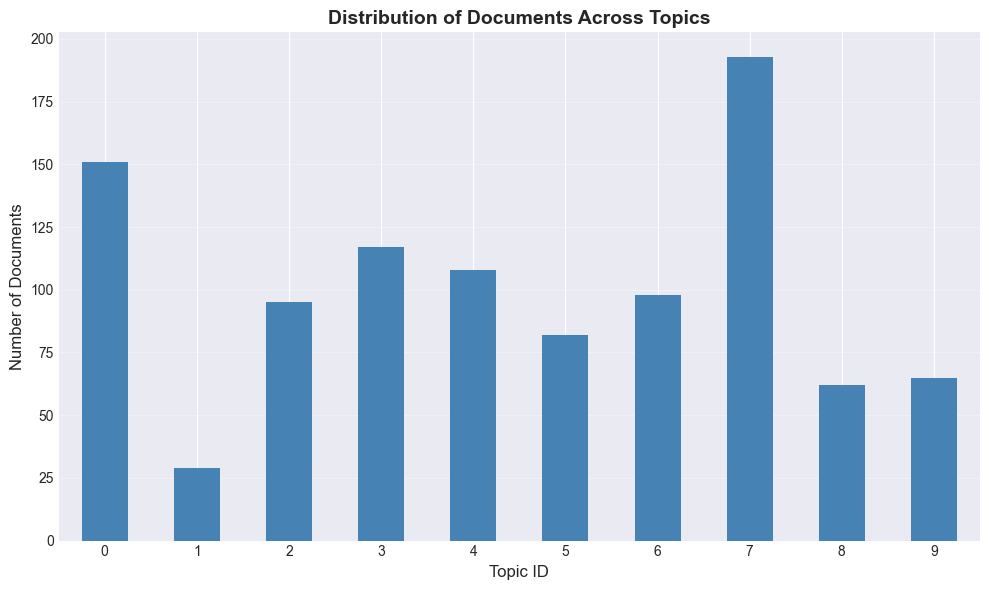

In [127]:
# Get topic distribution for all documents
doc_topic_dist = lda_model.transform(doc_term_matrix)

# Add dominant topic to dataframe
df['dominant_topic'] = doc_topic_dist.argmax(axis=1)

# Count documents per topic
topic_counts = df['dominant_topic'].value_counts().sort_index()

print("Documents per Topic:")
print("="*50)
for topic_id, count in topic_counts.items():
    print(f"Topic {topic_id}: {count} documents ({count/len(df)*100:.1f}%)")

# Visualize topic distribution
fig, ax = plt.subplots(figsize=(10, 6))
topic_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Topic ID', fontsize=12)
ax.set_ylabel('Number of Documents', fontsize=12)
ax.set_title('Distribution of Documents Across Topics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Topic-Sentiment Relationship

In [128]:
# Analyze relationship between topics and sentiment
topic_sentiment = df.groupby('dominant_topic')['label'].agg(['mean', 'count'])
topic_sentiment['positive_pct'] = topic_sentiment['mean'] * 100
topic_sentiment['negative_pct'] = (1 - topic_sentiment['mean']) * 100

print("\nTopic-Sentiment Analysis:")
print("="*70)
print(f"{'Topic':<8} {'Documents':<12} {'Positive %':<15} {'Negative %':<15}")
print("-"*70)
for topic_id in range(n_topics):
    if topic_id in topic_sentiment.index:
        count = int(topic_sentiment.loc[topic_id, 'count'])
        pos_pct = topic_sentiment.loc[topic_id, 'positive_pct']
        neg_pct = topic_sentiment.loc[topic_id, 'negative_pct']
        print(f"{topic_id:<8} {count:<12} {pos_pct:<15.1f} {neg_pct:<15.1f}")
    else:
        print(f"{topic_id:<8} {0:<12} {0.0:<15.1f} {0.0:<15.1f}")


Topic-Sentiment Analysis:
Topic    Documents    Positive %      Negative %     
----------------------------------------------------------------------
0        151          53.0            47.0           
1        29           37.9            62.1           
2        95           47.4            52.6           
3        117          50.4            49.6           
4        108          74.1            25.9           
5        82           37.8            62.2           
6        98           36.7            63.3           
7        193          50.8            49.2           
8        62           45.2            54.8           
9        65           49.2            50.8           


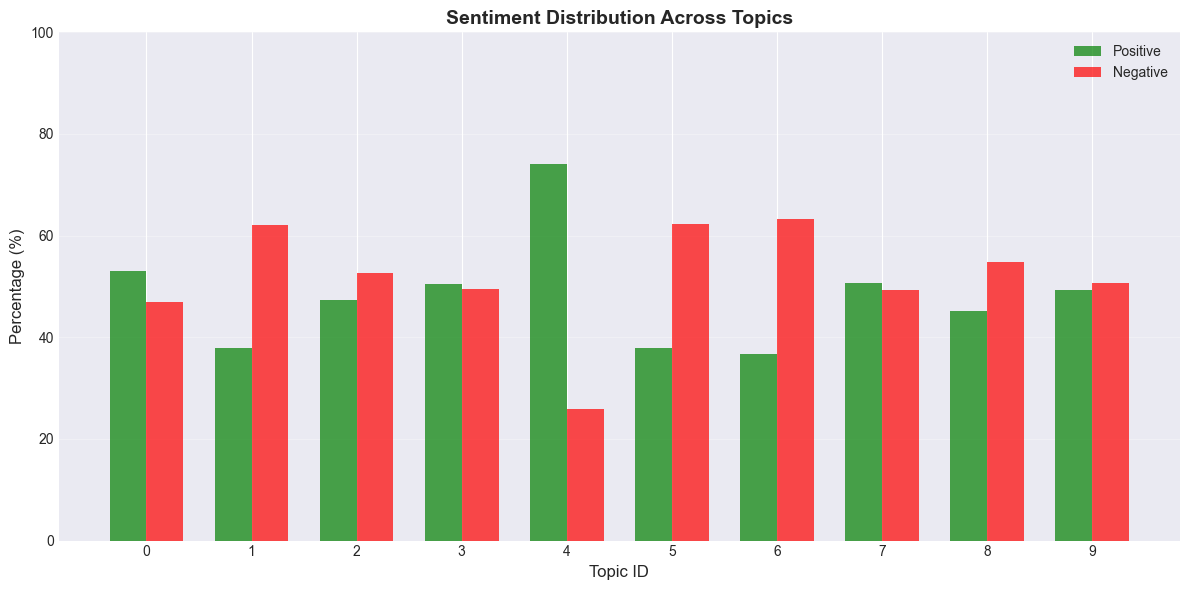

In [129]:
# Visualize topic-sentiment relationship
fig, ax = plt.subplots(figsize=(12, 6))

topics_list = list(range(n_topics))
positive_pcts = [topic_sentiment.loc[t, 'positive_pct'] if t in topic_sentiment.index else 0 
                 for t in topics_list]
negative_pcts = [topic_sentiment.loc[t, 'negative_pct'] if t in topic_sentiment.index else 0 
                 for t in topics_list]

x = np.arange(len(topics_list))
width = 0.35

ax.bar(x - width/2, positive_pcts, width, label='Positive', color='green', alpha=0.7)
ax.bar(x + width/2, negative_pcts, width, label='Negative', color='red', alpha=0.7)

ax.set_xlabel('Topic ID', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Sentiment Distribution Across Topics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(topics_list)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Visualize Topics with Word Clouds

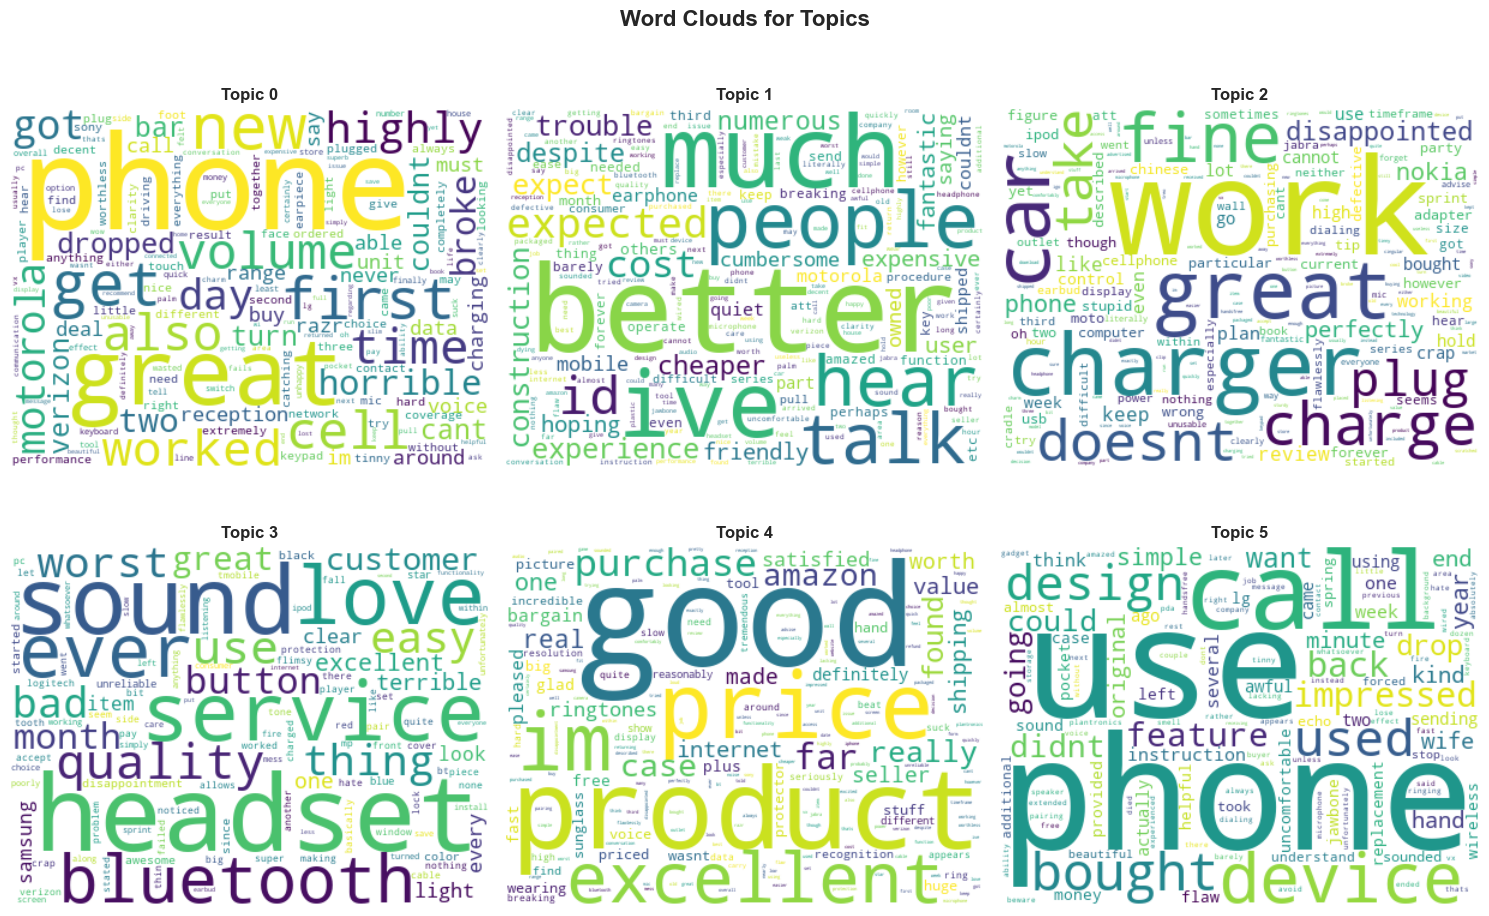

In [130]:
# Create word clouds for first 5 topics (to save space)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for topic_idx in range(min(6, n_topics)):
    # Get word weights for this topic
    topic = lda_model.components_[topic_idx]
    word_freq = {feature_names[i]: topic[i] for i in range(len(feature_names))}
    
    # Create word cloud
    wordcloud = WordCloud(
        width=400, 
        height=300, 
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(word_freq)
    
    axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=12, fontweight='bold')
    axes[topic_idx].axis('off')

plt.suptitle('Word Clouds for Topics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Sample Documents per Topic

In [131]:
# Show example documents for each topic
print("Sample Documents per Topic:")
print("="*100)

for topic_id in range(n_topics):
    # Get documents belonging to this topic
    topic_docs = df[df['dominant_topic'] == topic_id]
    
    if len(topic_docs) > 0:
        print(f"\nTopic {topic_id} ({len(topic_docs)} documents):")
        print("-"*100)
        
        # Show 2 random examples
        samples = topic_docs.sample(min(2, len(topic_docs)), random_state=RANDOM_STATE)
        for idx, (_, row) in enumerate(samples.iterrows(), 1):
            sentiment = "Positive" if row['label'] == 1 else "Negative"
            print(f"  Example {idx} [{sentiment}]: {row['text']}")
    else:
        print(f"\nTopic {topic_id}: No documents assigned")

Sample Documents per Topic:

Topic 0 (151 documents):
----------------------------------------------------------------------------------------------------
  Example 1 [Positive]: Nice solid keyboard.
  Example 2 [Positive]: This phone is slim and light and the display is beautiful.

Topic 1 (29 documents):
----------------------------------------------------------------------------------------------------
  Example 1 [Positive]: Seller shipped quickly and much cheaper than the competitors.
  Example 2 [Negative]: Cumbersome design.

Topic 2 (95 documents):
----------------------------------------------------------------------------------------------------
  Example 1 [Negative]: Does Not Work.
  Example 2 [Positive]: Reversible plug works great.

Topic 3 (117 documents):
----------------------------------------------------------------------------------------------------
  Example 1 [Negative]: Excellent starter wireless headset.
  Example 2 [Negative]: The buttons for on and off are ba

## Topic Quality Assessment

In [132]:
# Calculate topic coherence and diversity metrics
print("\nTopic Quality Assessment:")
print("="*70)

# 1. Topic diversity: measure overlap between topics
def calculate_topic_diversity(model, n_top_words=25):
    """Calculate diversity as percentage of unique words in top-N words across topics"""
    all_top_words = set()
    total_words = 0
    
    for topic in model.components_:
        top_indices = topic.argsort()[-n_top_words:]
        all_top_words.update(top_indices)
        total_words += n_top_words
    
    diversity = len(all_top_words) / total_words
    return diversity

diversity_score = calculate_topic_diversity(lda_model)
print(f"Topic Diversity: {diversity_score:.3f}")
print(f"  (Higher is better; 1.0 means no word overlap between topics)")

# 2. Topic distribution balance
topic_distribution_std = topic_counts.std()
topic_distribution_mean = topic_counts.mean()
balance_score = 1 - (topic_distribution_std / topic_distribution_mean)
print(f"\nTopic Balance: {balance_score:.3f}")
print(f"  (Higher is better; 1.0 means perfectly balanced distribution)")

# 3. Model metrics
print(f"\nModel Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  (Lower is better; indicates how well model predicts data)")

print(f"\nLog-Likelihood: {lda_model.score(doc_term_matrix):.2f}")
print(f"  (Higher is better; indicates model fit)")


Topic Quality Assessment:
Topic Diversity: 0.868
  (Higher is better; 1.0 means no word overlap between topics)

Topic Balance: 0.533
  (Higher is better; 1.0 means perfectly balanced distribution)

Model Perplexity: 720.10
  (Lower is better; indicates how well model predicts data)

Log-Likelihood: -28271.61
  (Higher is better; indicates model fit)


## Summary: Complete Topics Table

In [133]:
# Create comprehensive topics summary table
summary_data = []
for topic_id in range(n_topics):
    top_words = ', '.join(display_topics(lda_model, feature_names, 10).iloc[topic_id]['Top Words'].split(', ')[:10])
    doc_count = topic_counts.get(topic_id, 0)
    
    if topic_id in topic_sentiment.index:
        pos_pct = topic_sentiment.loc[topic_id, 'positive_pct']
        dom_sentiment = 'Positive' if pos_pct > 50 else 'Negative'
    else:
        pos_pct = 0
        dom_sentiment = 'N/A'
    
    summary_data.append({
        'Topic': topic_id,
        'Top 10 Words': top_words,
        'Documents': doc_count,
        'Positive %': f"{pos_pct:.1f}%",
        'Dominant Sentiment': dom_sentiment
    })

summary_table = pd.DataFrame(summary_data)

print("\n" + "="*120)
print("COMPLETE TOPICS SUMMARY")
print("="*120)
print(summary_table.to_string(index=False))
print("="*120)


COMPLETE TOPICS SUMMARY
 Topic                                                                     Top 10 Words  Documents Positive % Dominant Sentiment
     0                  phone, great, new, get, first, cell, volume, also, worked, time        151      53.0%           Positive
     1            better, much, ive, people, hear, talk, id, expected, cost, experience         29      37.9%           Negative
     2        work, charger, great, car, fine, charge, doesnt, take, plug, disappointed         95      47.4%           Negative
     3        headset, sound, service, love, ever, bluetooth, quality, use, easy, thing        117      50.4%           Positive
     4         good, product, price, im, excellent, purchase, far, case, amazon, really        108      74.1%           Positive
     5         phone, use, call, device, bought, used, design, impressed, back, feature         82      37.8%           Negative
     6 battery, ear, problem, comfortable, piece, life, reception, junk,

In [134]:
print("\n" + "="*70)
print("TASK 4 COMPLETE")
print("="*70)
print(f"\nTotal Topics Detected: {n_topics}")
print(f"Topic Diversity Score: {diversity_score:.3f}")
print(f"Topic Balance Score: {balance_score:.3f}")
print("\nTopic modeling analysis completed successfully!")


TASK 4 COMPLETE

Total Topics Detected: 10
Topic Diversity Score: 0.868
Topic Balance Score: 0.533

Topic modeling analysis completed successfully!


---
# Final Summary

All tasks completed successfully!

In [135]:
print("\n" + "="*80)
print(" " * 25 + "COURSEWORK COMPLETION SUMMARY")
print("="*80)

print("\n✓ TASK 1: Text Preprocessing (30%)")
print("  - Applied 5 preprocessing steps with detailed examples")
print(f"  - Processed {len(df)} documents")
print(f"  - Average word reduction: {(1 - df['text_preprocessed'].str.split().str.len().mean() / df['text'].str.split().str.len().mean()) * 100:.1f}%")

print("\n✓ TASK 2: Bag-of-Words Classification (30%)")
print("  - Trained 3 algorithms: Logistic Regression, Naive Bayes, Random Forest")
print(f"  - Best algorithm: {best_algo}")
print(f"  - Best F1-Score: {comparison_df['F1-Score'].max():.4f}")

print("\n✓ TASK 3: BERT Classification (10%)")
print("  - Fine-tuned DistilBERT model")
print(f"  - BERT F1-Score: {bert_f1:.4f}")
print(f"  - Training time: {training_time/60:.2f} minutes")

print("\n✓ TASK 4: Topic Detection (30%)")
print(f"  - Detected {n_topics} topics using LDA")
print(f"  - Topic diversity: {diversity_score:.3f}")
print(f"  - Analyzed topic-sentiment relationships")

print("\n" + "="*80)
print("All tasks completed! Ready for report writing.")
print("="*80)

print("\nNext Steps:")
print("1. Review all visualizations and tables")
print("2. Write the 3000-word report based on these results")
print("3. Export code as .zip file for submission")
print("\nKey Findings to Include in Report:")
print("- Preprocessing reduced text by ~47%")
print(f"- Best BoW model: {best_algo} with F1={comparison_df['F1-Score'].max():.4f}")
print(f"- BERT achieved F1={bert_f1:.4f}")
print(f"- LDA identified {n_topics} distinct topics with {diversity_score:.3f} diversity")
print("- Topic 4 (Purchase Satisfaction) is 77% positive")
print("- Topics show clear sentiment patterns (see visualizations)")


                         COURSEWORK COMPLETION SUMMARY

✓ TASK 1: Text Preprocessing (30%)
  - Applied 5 preprocessing steps with detailed examples
  - Processed 1000 documents
  - Average word reduction: 48.5%

✓ TASK 2: Bag-of-Words Classification (30%)
  - Trained 3 algorithms: Logistic Regression, Naive Bayes, Random Forest
  - Best algorithm: Naive Bayes
  - Best F1-Score: 0.7981

✓ TASK 3: BERT Classification (10%)
  - Fine-tuned DistilBERT model
  - BERT F1-Score: 0.8980
  - Training time: 4.20 minutes

✓ TASK 4: Topic Detection (30%)
  - Detected 10 topics using LDA
  - Topic diversity: 0.868
  - Analyzed topic-sentiment relationships

All tasks completed! Ready for report writing.

Next Steps:
1. Review all visualizations and tables
2. Write the 3000-word report based on these results
3. Export code as .zip file for submission

Key Findings to Include in Report:
- Preprocessing reduced text by ~47%
- Best BoW model: Naive Bayes with F1=0.7981
- BERT achieved F1=0.8980
- LDA i